In [3]:
%matplotlib widget
import ipywidgets as widgets
# from IPython.display import clear_output
import warnings
from tqdm import TqdmExperimentalWarning
warnings.filterwarnings("ignore", category=TqdmExperimentalWarning)

import matplotlib.pyplot as plt
# import seaborn as sns
# import pandas as pd
# import numpy as np
from tqdm.autonotebook import tqdm
from scipy.ndimage import gaussian_filter1d
# import h5py
# import copy
import os
import torch
os.environ['TORCH_CUDA_ARCH_LIST'] = f'{torch.cuda.get_device_properties(0).major}.{torch.cuda.get_device_properties(0).minor}'

# import shlex

from diffSPH.simple import *
from util import *

# from waveEqn import WaveEquationState, waveEquation2
# from waveEqn import WaveSystem, waveSystemFunction

In [4]:
device = torch.device('cuda:0') if torch.cuda.is_available() else torch.device('cpu')
device = torch.device('cpu')
dtype = torch.float64
L = 1
dim = 2
nx = 32
dx = L/nx

kernel = KernelType.Wendland4
targetNeighbors = n_h_to_nH(4, dim)

domain = buildDomainDescription(L, dim, True, device, dtype)
domain.min = torch.zeros_like(domain.min)
domain.max = torch.ones_like(domain.max) * L

# particles = sampleOptimal(nx, domain, targetNeighbors, kernel, 0.2, 128, shiftScheme = 'delta')
particles = sampleOptimal(nx, domain, targetNeighbors, kernel, 0.5, 128, shiftScheme = 'delta') 
particlesLR = sampleOptimal(nx//2, domain, targetNeighbors, kernel, 0., 0, shiftScheme = 'delta')

particles = particles._replace(positions = particles.positions - dx/2)
particlesLR = particlesLR._replace(positions = particlesLR.positions - dx/4)    

config = {
    'domain': domain,
    'kernel': kernel,
    'targetNeighbors': targetNeighbors,
    'neighborhood':{
        'verletScale': 1.0,
        'computeHessian': True,
    }
}

config['gradientMode'] = GradientMode.Difference
config['laplacianMode'] = LaplacianMode.Brookshaw
config['supportScheme'] = SupportScheme.Gather
config['integrationScheme'] = IntegrationSchemeType.rungeKutta4

particleState = wcstateToState(particles)


  0%|          | 0/128 [00:00<?, ?it/s]

0it [00:00, ?it/s]

  0%|          | 0/128 [00:00<?, ?it/s]

tensor(0.0003, dtype=torch.float64) tensor(0.9998, dtype=torch.float64)


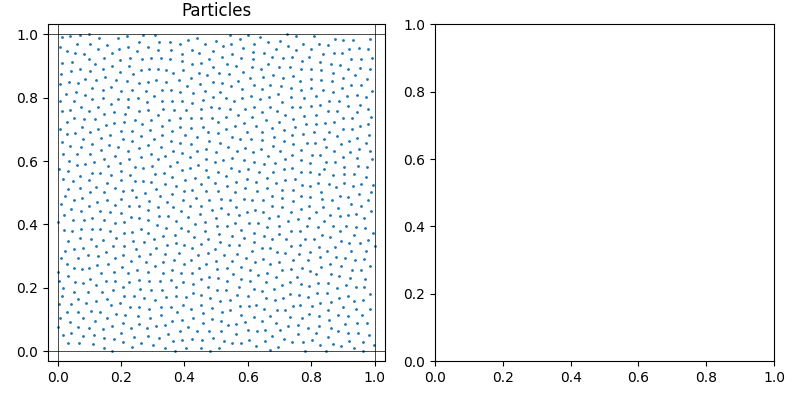

In [6]:
sets = 32


particles = sampleOptimal(nx, domain, targetNeighbors, kernel, 0.5, 128, shiftScheme = 'delta') 

positions = particles.positions

positions = positions % L

print(positions.min(), positions.max())

fig, axis = plt.subplots(1, 2, figsize=(8, 4), squeeze=False)

axis[0,0].scatter(positions[:,0].cpu(), positions[:,1].cpu(), s=1)
axis[0,0].set_title('Particles')
axis[0,0].set_aspect('equal')
axis[0,0].set_xlim(-dx, L+dx)
axis[0,0].set_ylim(-dx, L+dx)
axis[0,0].axhline(0, color='k', lw=0.5)
axis[0,0].axvline(0, color='k', lw=0.5)
axis[0,0].axhline(L, color='k', lw=0.5)
axis[0,0].axvline(L, color='k', lw=0.5)

fig.tight_layout()

In [7]:
import os
os.environ['XLA_PYTHON_CLIENT_PREALLOCATE'] = 'false'

In [8]:
import numpy as np
seeds = np.random.randint(0, np.iinfo(np.int32).max, size=64)
print(seeds)

import jax
import exponax as ex
import matplotlib.pyplot as plt
import h5py

nxs = [16, 32, 64, 128, 256, 512]

for nx in nxs:
    print(f"Running for nx = {nx}")
    NUM_POINTS = nx
    datafile = h5py.File(f"data_diffusedNoise_nx_{nx}.h5", "w")
    data_grp = datafile.create_group(f"data")

    us = []
    ds = []
    d2s = []
    d3s = []

    for seed in tqdm(seeds):
        seed_grp = data_grp.create_group(f"{seed}")

        u_0 = ex.ic.DiffusedNoise(2, max_one=True, zero_mean=True)(
            NUM_POINTS, key=jax.random.PRNGKey(seed)
        )


        cpu_device = jax.devices('cpu')[0]
        u_0 = u_0.to_device(device=cpu_device)

        # print(u_0.shape)
        d = ex.derivative(u_0, 1)
        # print(d.shape)

        d2 = ex.derivative(d, 1, order = 1)
        # print(d2.shape)
        d3 = ex.derivative(d2.reshape(dim**2, nx, nx), 1, order = 1).reshape(dim, dim, dim, nx, nx)
        # print(d3.shape)

        seed_grp.create_dataset("u_0", data=np.array(u_0))
        seed_grp.create_dataset("d", data=np.array(d))
        seed_grp.create_dataset("d2", data=np.array(d2))
        seed_grp.create_dataset("d3", data=np.array(d3))
        # print(f"Seed {seed} done.")

        us.append(u_0)
        ds.append(d)
        d2s.append(d2)
        d3s.append(d3)

        # break

    us = jax.numpy.stack(us, axis=0)
    ds = jax.numpy.stack(ds, axis=0)
    d2s = jax.numpy.stack(d2s, axis=0)
    d3s = jax.numpy.stack(d3s, axis=0)

    datafile.create_dataset("u_0", data=np.array(us))
    datafile.create_dataset("d", data=np.array(ds))
    datafile.create_dataset("d2", data=np.array(d2s))
    datafile.create_dataset("d3", data=np.array(d3s))

    datafile.close()

[ 890904437  361506665  850795585 2010987667 1644883828  395826470
  371864677  471003852 1907723794 1947229760  858658715  701114492
  290966754  871695028 1321257326 1735548520 1320104124 1942299852
  638632925   24316760  800834372 1504669492   85686085 1223124408
 2073452628  567819914 1930342364  503232535 1409977852    5505849
 1179987510  374955082 1108751544 1371570541 1904094019 1265297228
  129654366 1743398533 1276217373  541671886 1423208400  282748581
  240074581 1035915813  409441115 1257567280  356160870  771553853
   99336220 1496032209  723454394  330062278  506698725 1048425809
  178936106  156189721  100599341 1736317684   91257076 1662415556
  229689106  827152636  565716272 1870148577]
Running for nx = 16


  0%|          | 0/64 [00:00<?, ?it/s]

Running for nx = 32


  0%|          | 0/64 [00:00<?, ?it/s]

Running for nx = 64


...

  0%|          | 0/64 [00:00<?, ?it/s]

Running for nx = 256


  0%|          | 0/64 [00:00<?, ?it/s]

Running for nx = 512


  0%|          | 0/64 [00:00<?, ?it/s]

(64, 1, 128, 128)


(1, 128, 128) (2, 128, 128) (2, 2, 128, 128)


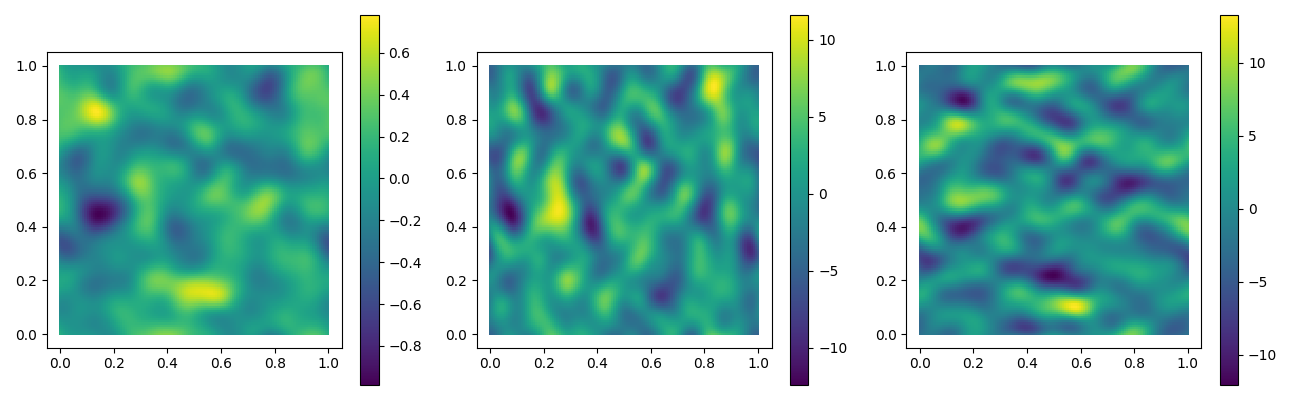

In [ ]:


print(u_0.shape, d.shape, d2.shape)

import numpy as np

convert = lambda x: torch.from_numpy(np.array(x))

u_0_torch = convert(u_0)
d_torch = convert(d)


fig, axis = plt.subplots(1, 3, figsize=(13, 4), squeeze = False)

plot = visualizeParticles(fig, axis[0, 0],
  particles = particleState,
  domain = domain,
  quantity = u_0_torch[0].flatten(),
  which = 'fluid',
  mapping = '.x',
  cmap = 'viridis',
  visualizeBoth=False,
  kernel = kernel,
  plotDomain = False,
  gridVisualization=True, markerSize=4,
  streamLines = False)

plot = visualizeParticles(fig, axis[0, 1],
  particles = particleState,
  domain = domain,
  quantity = d_torch[0].flatten(),
  which = 'fluid',
  mapping = '.y',
  cmap = 'viridis',
  visualizeBoth=False,
  kernel = kernel,  
  plotDomain = False,
  gridVisualization=True, markerSize=4,
  streamLines = False)


plot = visualizeParticles(fig, axis[0, 2],
  particles = particleState,
  domain = domain,
  quantity = d_torch[1].flatten(),
  which = 'fluid',
  mapping = '.x',
  cmap = 'viridis',
  visualizeBoth=False,
  kernel = kernel,
  plotDomain = False,
  gridVisualization=True, markerSize=4,
  streamLines = False)


fig.tight_layout()


In [135]:
grid_ex = ex.make_grid(2, 1, NUM_POINTS)

In [137]:
grid_ex.shape

(2, 128, 128)

In [141]:
grid_ex.max() - grid_ex.min()

Array(0.9921875, dtype=float32)

In [154]:
dx = L/nx
grid = torch.linspace(-L/2 + dx/ 2, L/2 - dx/2, nx, device=device, dtype=dtype)
X, Y = torch.meshgrid(grid, grid, indexing='ij')
grid_points = torch.stack([X.flatten(), Y.flatten()], dim=-1) /2 + 0.5 - dx/4

grid_points.max() - grid_points.min()
print(1 - dx/2)

0.9921875


In [170]:
locations = particles.positions# /2 + 0.5
# locations = grid_points

query_locations = jax.numpy.asarray(
    locations.cpu().T.view(-1, nx, nx).numpy(), dtype=jax.numpy.float64, device=cpu_device
)

# query_locations = grid_ex

print(query_locations.shape)  # (2, M, P)

interpolator = ex._interpolation.FourierInterpolator(u_0, domain_extent=1.0)
interpolated_values = jax.vmap(
    jax.vmap(interpolator, in_axes=-1, out_axes=-1), in_axes=-2,
    out_axes=-2,
)(query_locations)

print(interpolated_values.shape)  # (2, M, P)


(2, 128, 128)
(1, 128, 128)


In [171]:
diff = interpolated_values - u_0
print(jax.numpy.allclose(interpolated_values, u_0, atol=1e-5))
print(f'Minimum difference: {diff.min()}')
print(f'Maximum difference: {diff.max()}')
print(f'Mean difference: {(diff**2).mean()}')

True
Minimum difference: -8.344650268554688e-07
Maximum difference: 8.642673492431641e-07
Mean difference: 2.782257253362494e-14


In [158]:
diff = interpolated_values - u_0
print(jax.numpy.allclose(interpolated_values, u_0, atol=1e-5))
print(f'Minimum difference: {diff.min()}')
print(f'Maximum difference: {diff.max()}')
print(f'Mean difference: {(diff**2).mean()}')

True
Minimum difference: -8.344650268554688e-07
Maximum difference: 8.642673492431641e-07
Mean difference: 2.782257253362494e-14


Text(0.5, 1.0, 'Difference')

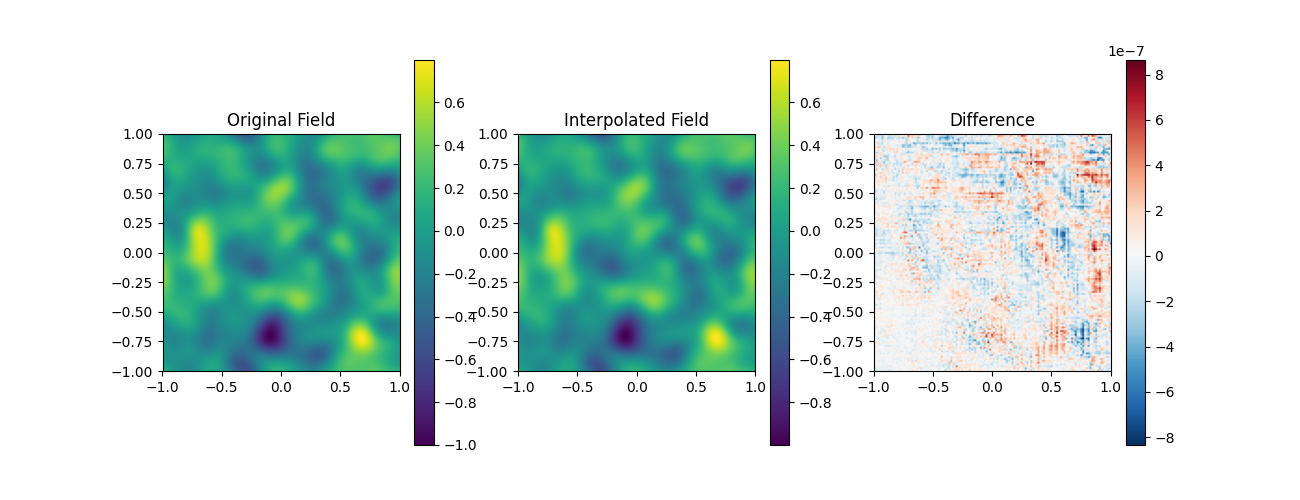

In [159]:
fig, axis = plt.subplots(1, 3, figsize=(13, 5), squeeze = False)

sc = axis[0,0].imshow(u_0[0], origin='lower', extent=(-1,1,-1,1))
fig.colorbar(sc, ax=axis[0,0])
axis[0,0].set_title('Original Field')
sc = axis[0,1].imshow(interpolated_values[0], origin='lower', extent=(-1,1,-1,1))
fig.colorbar(sc, ax=axis[0,1])
axis[0,1].set_title('Interpolated Field')
sc = axis[0,2].imshow((interpolated_values - u_0)[0], origin='lower', extent=(-1,1,-1,1), cmap = 'RdBu_r')
fig.colorbar(sc, ax=axis[0,2])
axis[0,2].set_title('Difference')


In [4]:
from diffSPH.finiteDifference import *

In [5]:
def buildRandomPolynomial(degree, dim, minCoeff = -1, maxCoeff = 1):
    coeffs = (maxCoeff - minCoeff) * torch.rand([degree+1]*dim, device=device, dtype=dtype) + minCoeff
    def polyFn(x):
        result = torch.zeros(x.shape[0], device=device, dtype=dtype)
        for index in torch.cartesian_prod(*[torch.arange(degree+1, device=device)]*dim):
            term = coeffs[tuple(index)]
            for d in range(dim):
                term = term * x[:,d]**index[d]
            result = result + term
        return result
    return polyFn, coeffs

In [6]:
def randomFourierSeries(numFreq, dim, minCoeff = -1, maxCoeff = 1):
    a_coeffs = (maxCoeff - minCoeff) * torch.rand([numFreq]*dim, device=device, dtype=dtype) + minCoeff
    b_coeffs = (maxCoeff - minCoeff) * torch.rand([numFreq]*dim, device=device, dtype=dtype) + minCoeff
    def fourierFn(x):
        result = torch.zeros(x.shape[0], device=device, dtype=dtype)
        for index in torch.cartesian_prod(*[torch.arange(numFreq, device=device)]*dim):
            term_a = a_coeffs[tuple(index)]
            term_b = b_coeffs[tuple(index)]
            for d in range(dim):
                term_a = term_a * torch.cos((index[d]+1) * x[:,d] * 2 * torch.pi / L)
                term_b = term_b * torch.sin((index[d]+1) * x[:,d] * 2 * torch.pi / L)
            result = result + term_a + term_b
        return result
    return fourierFn, a_coeffs, b_coeffs

In [7]:
def randomFourierSeries_Scaled(numFreq, dim, L, alpha, minCoeff=-1, maxCoeff=1):
    # 1. Generate unscaled random coefficients (A and B)
    base_coeffs = (maxCoeff - minCoeff) * torch.rand([numFreq] * dim, device=device, dtype=dtype) + minCoeff
    
    # Initialize the scaled coefficient tensors
    a_coeffs = torch.zeros_like(base_coeffs)
    b_coeffs = torch.zeros_like(base_coeffs)
    
    # Iterate over all frequency indices
    for index in torch.cartesian_prod(*[torch.arange(numFreq, device=device)] * dim):
        # Calculate the components of the wavenumber vector (k_d)
        # Note: index runs from 0 to numFreq-1, corresponding to modes 1 to numFreq
        n_plus_1 = index + 1
        k_d = n_plus_1 * (2 * torch.pi / L)
        
        # Calculate the magnitude of the wavenumber vector |k|
        k_mag = torch.sqrt(torch.sum(k_d**2))
        
        # Calculate the scaling factor S_k
        if k_mag == 0:
            # Handle the DC term (k=0) separately or skip if index starts at 1
            # Your current generation starts at index=0, which corresponds to modes 1, so k_mag is never zero.
            scale = 1.0 # Or 0 if you want to drop the DC-like term if you adjust the series form
        else:
            scale = k_mag**(-alpha) # The inverse power law decay

        # Scale and assign the coefficients
        a_coeffs[tuple(index)] = base_coeffs[tuple(index)] * scale
        b_coeffs[tuple(index)] = base_coeffs[tuple(index)] * scale

    # The rest of the function remains the same, using the scaled a_coeffs and b_coeffs
    def fourierFn(x):
        result = torch.zeros(x.shape[0], device=device, dtype=dtype)
        for index in torch.cartesian_prod(*[torch.arange(numFreq, device=device)]*dim):
            term_a = a_coeffs[tuple(index)]
            term_b = b_coeffs[tuple(index)]
            for d in range(dim):
                # k_d is (index[d]+1) * 2 * pi / L
                k_d_comp = (index[d]+1) * x[:,d] * 2 * torch.pi / L
                term_a = term_a * torch.cos(k_d_comp)
                term_b = term_b * torch.sin(k_d_comp)
            result = result + term_a + term_b
        return result
        
    return fourierFn, a_coeffs, b_coeffs

# Example Usage:
# alpha = 5/6 for a Kolmogorov-like distribution (turbulent velocity field)
# alpha = 1.5 to ensure continuous first derivative in 1D
# randomFourierSeries_Scaled(numFreq=10, dim=2, L=1.0, alpha=5/6)

In [36]:
fn = lambda x: x[:,0]**2

numFreq = 17
dim = 2
maxCoeff = 1
minCoeff = -1

def fn(x):
    x_hat = x[:,0] - 0.1453
    y_hat = x[:,1] - 0.16401

    c = 1.0
    prodTerm = (x_hat * y_hat)**4
    sumTerm = 0
    for i in range(1,7):
        sumTerm = sumTerm + x_hat**i + y_hat**i
    return c + prodTerm + sumTerm

# fn, coeffs = buildRandomPolynomial(7, 2)
fn, a_coeffs, b_coeffs = randomFourierSeries(numFreq, dim, minCoeff, maxCoeff)

# fn, a_coeffs, b_coeffs = randomFourierSeries_Scaled(numFreq, dim, L, 5/6, minCoeff, maxCoeff)

p_denorm = fn(particles.positions)

fn_normalized = lambda x: (fn(x) - p_denorm.min()) / (p_denorm.max() - p_denorm.min()) * 2 - 1
p = fn_normalized(particles.positions)

In [37]:
fn_max = 2 * (numFreq)**dim * maxCoeff
fn_min = 2 * (numFreq)**dim * minCoeff

print(f'Function value range: [{fn_min}, {fn_max}], [{p_denorm.min().item()}, {p_denorm.max().item()}]')

Function value range: [-578, 578], [-25.27036705492937, 26.47597849156537]


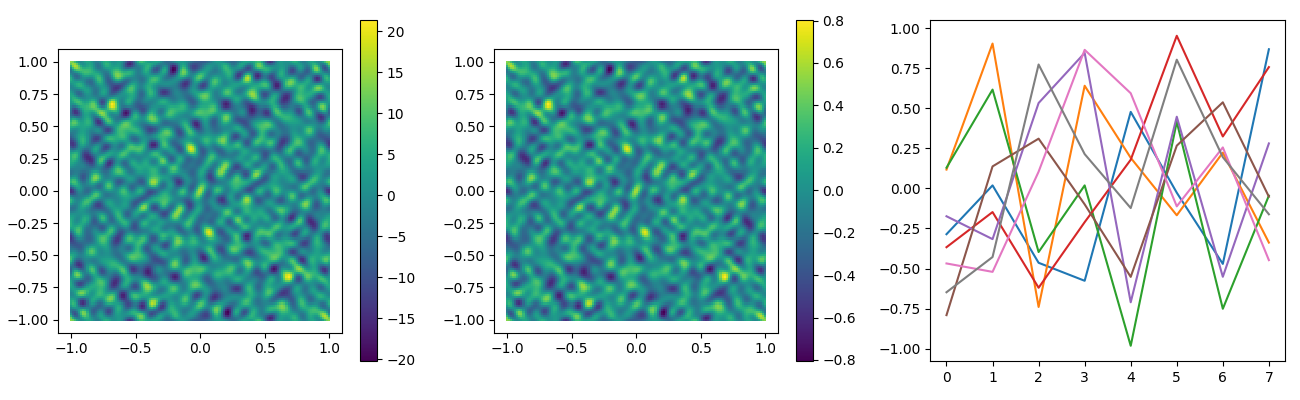

In [38]:


fig, axis = plt.subplots(1, 3, figsize=(13, 4), squeeze = False)

plot = visualizeParticles(fig, axis[0, 0],
  particles = particleState,
  domain = domain,
  quantity = p_denorm,
  which = 'fluid',
  mapping = '.x',
  cmap = 'viridis',
  visualizeBoth=False,
  kernel = kernel,
  plotDomain = False,
  gridVisualization=True, markerSize=4,
  streamLines = False)

plot = visualizeParticles(fig, axis[0, 1],
  particles = particleState,
  domain = domain,
  quantity = p,
  which = 'fluid',
  mapping = '.x',
  cmap = 'viridis',
  visualizeBoth=False,
  kernel = kernel,
  plotDomain = False,
  gridVisualization=True, markerSize=4,
  streamLines = False)

axis[0,2].plot(coeffs)

fig.tight_layout()


In [39]:
order = 3
accuracy = 4
# from diffSPH.v2.finiteDifference import centralDifferenceStencil, continuousGradient
stencil = centralDifferenceStencil(order, 4)

stencil = (stencil[0], torch.arange(-len(stencil[0])//2 + 1, len(stencil[0])//2 + 1, device=device))
print(stencil)
finite_Gradient = continuousGradient(fn, particles.positions, stencil[0], stencil[1], 1e-3, order)

finite_Gradient

(tensor([ 0.1250, -1.0000,  1.6250,  0.0000, -1.6250,  1.0000, -0.1250]), tensor([-3, -2, -1,  0,  1,  2,  3]))


tensor([[  680370.5132,   777309.0711],
        [ 1312392.0174,  1187182.5286],
        [ 1495353.0564,   978558.3721],
        ...,
        [-1495353.0564,  -978558.3721],
        [-1312392.0174, -1187182.5286],
        [ -680370.5132,  -777309.0711]], dtype=torch.float64)

In [40]:
from diffSPH.gradientUtil import *

In [42]:

positions_g = particles.positions.clone()
positions_g.requires_grad = True

grad = eval_fn_grad(fn, positions_g, order = 2)


In [43]:
for t in grad:
    print(t.shape)

torch.Size([16384])
torch.Size([16384, 2])
torch.Size([16384, 2, 2])


In [44]:
grad[0]

tensor([14.4559,  6.2073, -2.8443,  ..., -2.8443,  6.2073, 14.4559],
       dtype=torch.float64, grad_fn=<AddBackward0>)

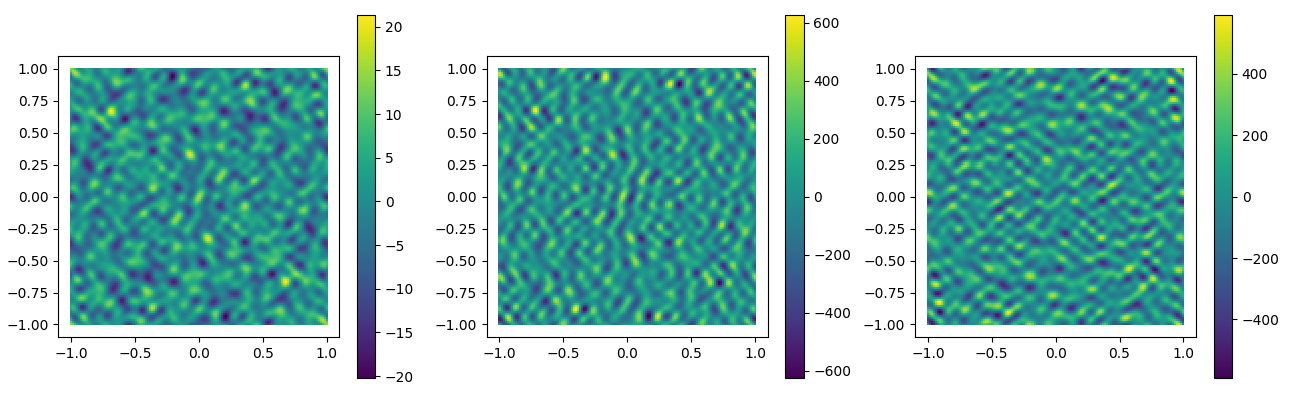

In [45]:
fig, axis = plt.subplots(1, 3, figsize=(13, 4), squeeze = False)
# filteredNeighborhood = filterNeighborhoodByKind(currentStates[0], neighborhoods[0], 'noghost')

# plots = []
axes = axis.flatten()
plot = visualizeParticles(fig, axes[0],
  particles = particleState,
  domain = domain,
  quantity = grad[0],
  which = 'fluid',
  mapping = '.x',
  cmap = 'viridis',
  visualizeBoth=False,
  kernel = kernel,
  plotDomain = False,
  gridVisualization=True, markerSize=4,
  streamLines = False)

plot = visualizeParticles(fig, axes[1],
  particles = particleState,
  domain = domain,
  quantity = grad[1][:,0],
  which = 'fluid',
  mapping = '.x',
  cmap = 'viridis',
  visualizeBoth=False,
  kernel = kernel,
  plotDomain = False,
  gridVisualization=True, markerSize=4,
  streamLines = False)

plot = visualizeParticles(fig, axes[2],
  particles = particleState,
  domain = domain,
  quantity = grad[1][:,1],
  which = 'fluid',
  mapping = '.x',
  cmap = 'viridis',
  visualizeBoth=False,
  kernel = kernel,
  plotDomain = False,
  gridVisualization=True, markerSize=4,
  streamLines = False)

fig.tight_layout()

In [46]:
from diffSPH.neighborhood import evaluateNeighborhood, filterNeighborhoodByKind, coo_to_csr, SparseNeighborhood
def buildSparseNeighborhood(neighborhood):
    i = neighborhood.row
    j = neighborhood.col

    return SparseNeighborhood(
        row = i,
        col = j,
        numRows = neighborhood.numRows,
        numCols = neighborhood.numCols,

        points_a = neighborhood.points_a,
        points_b = neighborhood.points_b,

        domain = neighborhood.domain,
    )

In [47]:
from diffSPH.dataLoaderUtils.resume import stateToState

state, particleSystem, config, domain, wrappedKernel, simulator, SimulationSystem, integrator, dt = stateToState(currentState, configs, domains, batch=0)
particles = particleSystem.systemState

NameError: name 'currentState' is not defined

In [10]:
from diffSPH.neighborhood import buildNeighborhood, computeNeighborhoodStates, filterNeighborhoodByKind, coo_to_csr
import numpy as np


mode = SupportScheme.SuperSymmetric
mode_str = mode.name
mode_str = mode_str[0].lower() + mode_str[1:]

neighborhood, sparseNeighborhood_ = buildNeighborhood(particles, particles, domain, verletScale = 1.4, mode = mode_str, priorNeighborhood=None)
neighbors = computeNeighborhoodStates(particles, sparseNeighborhood_, mode_str, kernel, kernel, True, False, False)

numNeighbors = coo_to_csr(neighbors.neighbors).rowEntries
# particleState.densities = computeDensity(particleState, kernel, neighbors.get('noghost'), SupportScheme.Gather, config)



In [11]:
# particleState = wcstateToState(particles)
particleState = particleSystem.systemState
# neighborhood, neighbors = evaluateNeighborhood(particleState, config['domain'], kernel, verletScale = config['neighborhood']['verletScale'], mode = SupportScheme.SuperSymmetric, priorNeighborhood=None)

# numNeighbors = coo_to_csr(filterNeighborhoodByKind(particleState, neighbors.neighbors, which = 'noghost')).rowEntries
# particleState.densities = computeDensity(particleState, kernel, neighbors.get('noghost'), SupportScheme.Gather, config)

In [12]:
config['domain']

DomainDescription(min=tensor([-1.2000, -1.2000], device='cuda:0'), max=tensor([1.2000, 1.2000], device='cuda:0'), periodic=tensor([False, False], device='cuda:0'), dim=2)

In [13]:
traj = (trajectoryStates[0].positions - currentState.positions) / currentState.dt[0]
print('traj:', traj)
print(f'max: {traj.max()}, min: {traj.min()}, mean: {traj.mean()}, std: {traj.std()}')

traj: tensor([[ 0.0030,  0.0131],
        [ 0.0061, -0.0092],
        [ 0.0066, -0.0021],
        ...,
        [ 0.0000,  0.0000],
        [ 0.0000,  0.0000],
        [ 0.0000,  0.0000]], device='cuda:0')
max: 1.3402401208877563, min: -1.0831652879714966, mean: -0.0007367254584096372, std: 0.3900046646595001


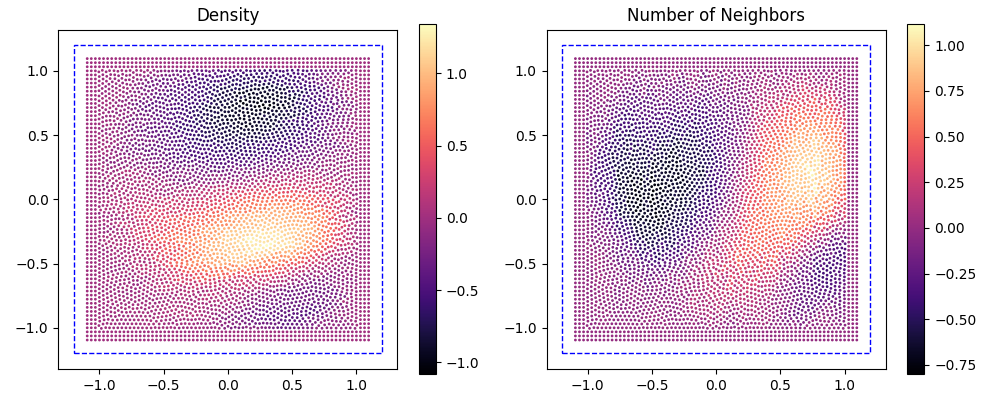

In [14]:
fig, axis = plt.subplots(1,2 , figsize=(10,4), squeeze=False)
markerSize = 1
visualizeParticles(fig, axis[0,0], particleState, config['domain'], traj, 
    kernel, which = 'both', visualizeBoth = True, cbar = True, cmap = 'magma', mapping = '.x',markerSize = markerSize, gridVisualization = False, title = 'Density')

visualizeParticles(fig, axis[0,1], particleState, config['domain'], traj, 
    kernel, which = 'both', visualizeBoth = True, cbar = True, cmap = 'magma', mapping = '.y',markerSize = markerSize, gridVisualization = False, title = 'Number of Neighbors')

# plotDistribution(fig, axis[0,1], particleState, neighbors.get('noghost'), 63)
fig.tight_layout()

In [15]:
from ml import *
print(config)

{'targetNeighbors': 20, 'domain': DomainDescription(min=tensor([-1.2000, -1.2000], device='cuda:0'), max=tensor([1.2000, 1.2000], device='cuda:0'), periodic=tensor([False, False], device='cuda:0'), dim=2), 'kernel': None, 'correctiveOmega': True, 'neighborhood': {'scheme': 'compact', 'verletScale': 1.4}, 'support': {'iterations': 1, 'adaptiveHThreshold': 0.01, 'scheme': <AdaptiveSupportScheme.OwenScheme: 1>, 'targetNeighbors': 20, 'LUT': None}, 'fluid': {'rho0': 1000, 'cs': 20}, 'diffusion': {'alpha': 0.01}, 'diffusionSwitch': {'scheme': <ViscositySwitch.NoneSwitch: 6>, 'limitXi': False}, 'shifting': {'CFL': 1.5}, 'surfaceDetection': {'active': False}, 'pressure': {'term': 'Antuono'}, 'gravity': {'active': False}, 'regions': [], 'energyScheme': 'CRK', 'schemeName': 'CompSPH - NoneSwitch - Wendland2 - symplecticEuler', 'scheme': <SimulationScheme.DeltaSPH: 7>, 'integrationScheme': <IntegrationSchemeType.symplecticEuler: 13>, 'compute': {'device': 'cuda', 'dtype': torch.float32, 'precisi

In [16]:
inputFeatures = torch.cat([
    particleState.velocities,
    particleState.densities[:, None] / config['fluid']['rho0'],  # normalized density
    torch.ones_like(particleState.velocities[:, 0])[:, None],  # bias term
], dim = 1).to(device)

gt = traj.to(device)  # ground truth densities
gt = (particleState.densities[:, None] / config['fluid']['rho0'])[:, None].to(device)

gt = (trajectoryStates[0].velocities - currentState.velocities).to(device) / currentState.dt[0]

print(f'GT statistics: max: {gt.max()}, min: {gt.min()}, mean: {gt.mean()}, std: {gt.std()}')

GT statistics: max: 6.38854455947876, min: -6.880998134613037, mean: -0.06251494586467743, std: 1.0979459285736084


In [17]:
print(inputFeatures, gt)

tensor([[ 0.0029,  0.0132,  0.9984,  1.0000],
        [ 0.0061, -0.0092,  0.9983,  1.0000],
        [ 0.0066, -0.0019,  0.9983,  1.0000],
        ...,
        [ 0.0000,  0.0000,  0.9980,  1.0000],
        [ 0.0000,  0.0000,  0.9980,  1.0000],
        [ 0.0000,  0.0000,  0.9980,  1.0000]], device='cuda:0') tensor([[ 0.1307, -0.2466],
        [-0.2101, -0.0268],
        [-0.0989, -0.2397],
        ...,
        [ 0.0000,  0.0000],
        [ 0.0000,  0.0000],
        [ 0.0000,  0.0000]], device='cuda:0')


In [18]:
latentSpaceSize = 17
hiddenMLPSize = 61
hiddenMLPLayers = 2

inputEncoderLayers = 0
outputDecoderLayers = 0

In [19]:
# inputEncoder = buildMLPwDict({
#  'inputFeatures': inputFeatures.shape[1],
#  'output' : 48,
#  'activation': 'celu',
#  'layout': [hiddenMLPSize] * inputEncoderLayers,
#  'norm': False,
#  'bias': False,
# }
# ).to(device)

# numberOfParameters = sum(p.numel() for p in inputEncoder.parameters())
# print(f'Number of parameters in input encoder: {numberOfParameters}')

# for i, layer in enumerate(inputEncoder):
#     print(f'Layer {i}: {layer}')

# encodedInput = inputEncoder(inputFeatures)
# encodedInputLR = inputEncoder(inputFeaturesLR)

In [20]:
from diffSPH.neighborhood import computeSparseDistanceTensor, filterNeighborhood, SparseNeighborhood, NeighborhoodInformation

# @torch.jit.script
def filterNeighborhood(neighborhood: SparseNeighborhood, mode: str = 'superSymmetric'):
    if isinstance(neighborhood, NeighborhoodInformation):
        raise ValueError('Cannot filter neighborhood with NeighborhoodInformation')

    # adjacency = neighborhood.fullAdjacency
    row, col = neighborhood.row, neighborhood.col
    rij, xij = computeSparseDistanceTensor(neighborhood, normalize = True, mode = mode)
    mask = rij <= 1
    # print(mask)
    # print(rij, 'max: ', rij.max().item())
    # print(torch.sum(mask).item(), 'out of', rij.shape[0], 'edges kept')
    return SparseNeighborhood(row[mask], col[mask], numRows = neighborhood.numRows, numCols = neighborhood.numCols,
                                points_a = neighborhood.points_a, points_b = neighborhood.points_b,
                                domain = neighborhood.domain)


print(neighbors.neighbors.row.shape)
filteredNeighborhood = filterNeighborhood(neighbors.neighbors, mode = 'gather')
# filteredNeighborhood = neighbors.neighbors

print(filteredNeighborhood.row.shape)


h_i = particleState.supports[filteredNeighborhood.row].to(device)
rij, xij_ = computeSparseDistanceTensor(filteredNeighborhood, normalize = False)
sparse_edge_attr = xij_ / h_i[:,None]

print('Maximum distance: ', (rij / h_i).max().item())


# minD = domain.min
# maxD = domain.max
# periodicity = domain.periodic

# dense_xij = (particleState.positions[:,None] - particleState.positions)
# dense_mod_xij = torch.stack([dense_xij.reshape(nx**4, 2)[:,i] if not periodic_i else mod(dense_xij.reshape(nx**4, 2)[:,i], minD[i], maxD[i]) for i, periodic_i in enumerate(periodicity)], dim = -1).reshape(nx**2, nx**2, dim)

# print('dense_xij', dense_mod_xij.shape)
# print(dense_mod_xij.min())

torch.Size([93886])
torch.Size([93886])
Maximum distance:  0.999998152256012


In [21]:
torch.cuda.empty_cache()

In [22]:
from util import *
# adjacency = buildDenseNeighborhood(particleState, domain)
adjacency = buildSparseNeighborhood(filteredNeighborhood)

In [23]:
def count_parameters(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

In [24]:
h_i = particleState.supports[adjacency.row].to(device)
rij, xij_ = computeSparseDistanceTensor(adjacency, normalize = False, mode = 'gather')

edge_attr = xij_ / h_i[:,None]
edge_index = torch.stack([adjacency.row, adjacency.col])
print('edge_attr shape:', edge_attr.shape)
print('edge_index shape:', edge_index.shape)

transformerFeatures = 11
multiHeads = 3
batch_size = 1
num_nodes = inputFeatures.shape[0]
latentSpaceSize = 17
dim = edge_attr.shape[-1]

node_attr = (inputFeatures.reshape(1, -1, inputFeatures.shape[-1]), inputFeatures.reshape(1, -1, inputFeatures.shape[-1]))  # Reshape to [B, N, F] for batch processing

print('node_attr shape:', node_attr[0].shape, node_attr[1].shape)

bs = 1
node_attr_batched = (inputFeatures.repeat(bs, 1, 1), inputFeatures.repeat(bs, 1, 1))  # Repeat for batch size
edge_attr_batched = edge_attr.repeat(bs, 1)  # Repeat edge attributes for batch size
edge_indices_batched = []
cumRows = 0
cumCols = 0
for i in range(bs):
    rows = edge_index[0] + cumRows
    cols = edge_index[1] + cumCols
    cumRows += particleState.positions.shape[0]
    cumCols += particleState.positions.shape[0]
    edge_indices = torch.stack([rows, cols])
    edge_indices_batched.append(edge_indices)
    print(f'Edge indices for batch {i}: {edge_indices.shape}')
edge_indices_batched = torch.cat(edge_indices_batched, dim=1)  # Concatenate all edge indices for batch processing

node_positions = (particleState.positions.reshape(1, -1, particleState.positions.shape[-1]).repeat(bs, 1, 1), particleState.positions.reshape(1, -1, particleState.positions.shape[-1]).repeat(bs, 1, 1 ))  # Reshape to [B, N, D] for batch processing

print('node_positions shape:', node_positions[0].shape, node_positions[1].shape)

print('node_attr_batched shape:', node_attr_batched[0].shape, node_attr_batched[1].shape)
print('edge_attr_batched shape:', edge_attr_batched.shape)
print('edge_indices_batched shape:', edge_indices_batched.shape)


e_ij = torch.cat([edge_attr_batched, torch.linalg.norm(edge_attr_batched, dim=-1, keepdim=True),], dim=-1)
print(e_ij.shape)

spatial_features = edge_attr_batched
# rpb_features = basisEncoder(spatial_features).squeeze(0)

from layers.windows import getWindowFunction

windowValues = getWindowFunction('cubicSpline', norm = None)(torch.linalg.norm(edge_attr_batched, dim=-1))

edge_attr shape: torch.Size([93886, 2])
edge_index shape: torch.Size([2, 93886])
node_attr shape: torch.Size([1, 4900, 4]) torch.Size([1, 4900, 4])
Edge indices for batch 0: torch.Size([2, 93886])
node_positions shape: torch.Size([1, 4900, 2]) torch.Size([1, 4900, 2])
node_attr_batched shape: torch.Size([1, 4900, 4]) torch.Size([1, 4900, 4])
edge_attr_batched shape: torch.Size([93886, 2])
edge_indices_batched shape: torch.Size([2, 93886])
torch.Size([93886, 3])


In [25]:
from models.basicEncoder import BasicEncoder

# encoder = BasicEncoder(
#     input_dim = node_attr_batched[0].shape[-1],
#     output_dim = transformerFeatures * multiHeads,
#     hidden_layers = 2,
#     latent_dim = 32,
#     verbose = False,
# ).to(device)
# decoder = BasicEncoder(
#     input_dim = transformerFeatures * multiHeads,
#     output_dim = gt.shape[-1],
#     hidden_layers = 2,
#     latent_dim = 32,
#     verbose = False,
# ).to(device)

In [26]:
from models.common import CommonConfiguration
import copy


In [27]:
from models.basicTransformer import BasicTransformer
from models.ContinuousConvolution import CConvModel, BasicCConvLayer
from models.GNN import GNNModel



In [62]:
class basicTest(nn.Module):
    def __init__(self, 
                 input_dim, output_dim,
                 transformer_features, multi_heads,
                 latent_dim, latent_layers,
                 encoderConfig, decoderConfig, transformerConfig, 
                 numTransformers, mode = 'transformer'):
        super(basicTest, self).__init__()
        self.inputEncoder = BasicEncoder(
            input_dim = input_dim,
            output_dim = transformer_features * multi_heads,
            hidden_layers = latent_layers,
            latent_dim = latent_dim,
            verbose = False,
        )
        self.transformers = nn.ModuleList()
        for _ in range(numTransformers):
            if mode == 'transformer':
                transformer = BasicTransformer(
                    config = transformerConfig,
                    transformer_features = transformer_features,
                    attention_heads = multi_heads,

                    # attention_softmax = False,

                    verbose = False,
                )
            elif mode == 'cconv':
                transformer = CConvModel(
                    config=baseConfigNoEncoders,

                    verbose = False,
                )
            elif mode == 'gnn':
                transformer = GNNModel(
                    config = baseConfigNoEncoders,

                    use_edge_mlp=True,
                    use_edge_encoder = True,
                    inputEdgeEncoderTokenConfig = None,
                    verbose = False,
                )
            self.transformers.append(transformer)
        self.decoder = BasicEncoder(
            input_dim = transformer_features * multi_heads,
            output_dim = output_dim,
            hidden_layers = latent_layers,
            latent_dim = latent_dim,
            verbose = False,
        )

    def forward(self, node_attr, edge_attr, edge_index, node_positions):
        # print('Input node_attr shape:', node_attr.shape)
        x = self.inputEncoder(node_attr, inputPositions = node_positions)
        # print('Encoded input shape:', x.shape)
        for transformer in self.transformers:
            x = transformer(
                node_features = x,
                node_positions = node_positions[0],
                edge_indices = edge_index,
                edge_features = None,
                edge_spatial_features = edge_attr)
            # print('Transformed shape:', x.shape)
        out = self.decoder(x, inputPositions = node_positions)
        # print('Output shape:', out.shape)
        return out

multiHeads = 4
transformerFeatures = 11



baseConfigNoEncoders = CommonConfiguration(
    token_input_dim=transformerFeatures * multiHeads,
    token_output_dim=transformerFeatures * multiHeads,
    spatial_dim=dim,
    edge_feature_dim=0,

    latent_features=transformerFeatures * multiHeads,
    hidden_layers=4,

    use_encoder=False,
    inputEncoderTokenConfig = None,

    use_decoder=False,
    outputDecoderTokenConfig = None,

    basis_function = 'ffourier',
    basis_terms = 6,
    basis_mode = 'cat',
    basis_projection = 'cartesian',

    mlp_hidden_layers=2,
    mlp_latent_dim = 32,
    mlp_activation = 'silu',
)

baseConfig = copy.deepcopy(baseConfigNoEncoders)
baseConfig.use_encoder=True
baseConfig.use_decoder=True
baseConfig.token_input_dim=node_attr_batched[0].shape[-1]
baseConfig.token_output_dim=1
baseConfig.ffn_skip_last = True

basicModel = basicTest(
    input_dim = node_attr_batched[0].shape[-1],
    output_dim = gt.shape[-1],
    transformer_features = transformerFeatures,
    multi_heads = multiHeads,
    latent_dim = 32,
    latent_layers = 2,
    encoderConfig = None,
    decoderConfig = None,
    transformerConfig = baseConfigNoEncoders,
    numTransformers = 2,
    mode = 'transformer'
).to(device)

In [63]:
optimizer = torch.optim.Adam(basicModel.parameters(), lr=1e-2)
numberOfParameters = count_parameters(basicModel)
print(f'Number of parameters in the model: {numberOfParameters}')



basicPred = basicModel(node_attr_batched[0], edge_attr_batched, edge_indices_batched, node_positions[0]).squeeze(0)


print(basicPred)


Number of parameters in the model: 99904
tensor([[ 1.2176e-05, -1.7462e-04],
        [ 1.2176e-05, -1.7462e-04],
        [ 1.2176e-05, -1.7462e-04],
        ...,
        [ 1.2176e-05, -1.7462e-04],
        [ 1.2176e-05, -1.7462e-04],
        [ 1.2176e-05, -1.7462e-04]], device='cuda:0',
       grad_fn=<SqueezeBackward1>)


In [52]:
losses_transformer2 = []
for i in (tq := tqdm(range(2**14), desc='Training', unit='epoch')) :
    optimizer.zero_grad()
    basicPred = basicModel(node_attr_batched[0], edge_attr_batched, edge_indices_batched, node_positions[0]).squeeze(0)

    # print(basicPred.shape, gt.shape)
    # print(basicPred)
    fluidPred = basicPred[particleState.kinds == 0]
    fluidGT = gt[particleState.kinds == 0]

    fluidLoss = torch.nn.functional.mse_loss(fluidPred, fluidGT)
    # print('Fluid loss:', fluidLoss.item())

    # loss = torch.nn.functional.mse_loss(basicPred, gt)
    fluidLoss.backward()
    optimizer.step()
    tq.set_postfix({'loss': fluidLoss.item()})
    losses_transformer2.append(fluidLoss.item())

    # break

Training:   0%|          | 0/16384 [00:00<?, ?epoch/s]

In [64]:
fluidPred

tensor([[-0.0256, -0.3350],
        [-0.2464, -0.0208],
        [-0.2066, -0.1523],
        ...,
        [ 0.4167,  0.0299],
        [-0.1797,  0.3716],
        [-1.9295, -0.1846]], device='cuda:0', grad_fn=<IndexBackward0>)

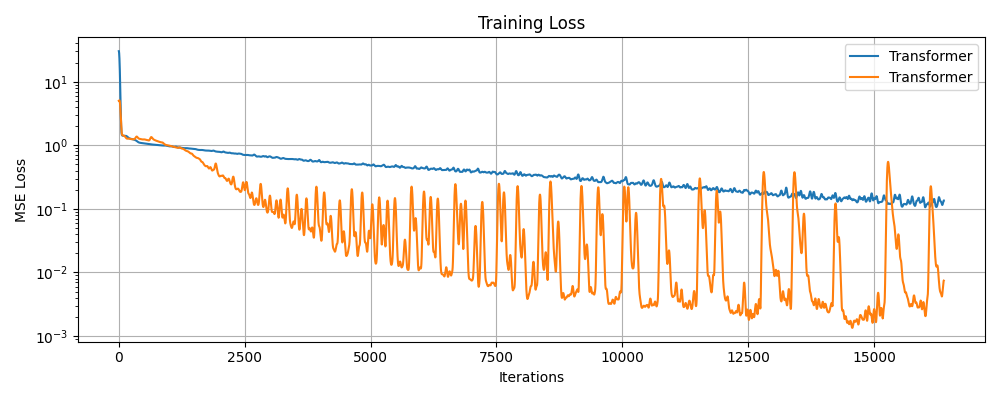

In [ ]:
fig, axis = plt.subplots(1,1 , figsize=(10,4), squeeze=False)

# axis[0,0].plot(gaussian_filter1d(losses, sigma=16), label = 'GNN')
axis[0,0].plot(gaussian_filter1d(losses_transformer, sigma=16), label = 'Transformer')
axis[0,0].plot(gaussian_filter1d(losses_transformer2, sigma=16), label = 'Transformer')
# axis[0,0].plot(gaussian_filter1d(losses_cconv, sigma=16), label = 'CConv')

axis[0,0].set_yscale('log')
axis[0,0].set_title('Training Loss')
axis[0,0].legend()

axis[0,0].grid(True)
axis[0,0].set_xlabel('Iterations')
axis[0,0].set_ylabel('MSE Loss')

fig.tight_layout()

In [ ]:

pred = basicPred.squeeze(0)

print('pred shape:', pred.shape, 'gt shape:', gt.shape)

loss = torch.nn.functional.mse_loss(pred, gt)
print('Loss:', loss.item())

pred shape: torch.Size([17196, 2]) gt shape: torch.Size([17196, 2])
Loss: 0.06757645308971405


In [ ]:
from models.ContinuousConvolution import CConvModel, BasicCConvLayer
from models.GNN import GNNModel


cconvModel = CConvModel(
    config=baseConfig,

    verbose = False,
).to(device)

cconvModelNoEncoders = CConvModel(
    config=baseConfigNoEncoders,

    verbose = False,
).to(device)


In [ ]:
outA = cconvModel(
    node_features = node_attr_batched[0],
    node_positions = node_positions[0],
    edge_indices = edge_indices_batched,
    edge_features = None,
    edge_spatial_features = edge_attr_batched
)
outB = decoder(cconvModelNoEncoders(
    node_features = encodedNodes[0],
    node_positions = node_positions[0],
    edge_indices = edge_indices_batched,
    edge_features = None,
    edge_spatial_features = edge_attr_batched
))

In [ ]:
from models.GNN import GNNModel

gnn = GNNModel(
    config = baseConfig,

    use_edge_mlp=True,
    use_edge_encoder = True,
    inputEdgeEncoderTokenConfig = None,
    verbose = False,
).to(device)

gnnNoEncoders = GNNModel(
    config = baseConfigNoEncoders,

    use_edge_mlp=True,
    use_edge_encoder = True,
    inputEdgeEncoderTokenConfig = None,
    verbose = False,
).to(device)

In [ ]:
outA = gnn(
    node_features = node_attr_batched[0],
    node_positions = node_positions[0],
    edge_indices = edge_indices_batched,
    edge_features = None,
    edge_spatial_features = edge_attr_batched
)
outB = decoder(gnnNoEncoders(
    node_features = encodedNodes[0],
    node_positions = node_positions[0],
    edge_indices = edge_indices_batched,
    edge_features = None,
    edge_spatial_features = edge_attr_batched
))